# Ubunifu Madness — V3 Model (Modern Era)

**Key changes from V2:**
- Training on **2012+** only (modern basketball era — 3pt revolution, transfer portal, NIL)
- **Optuna re-tuning** of Elo parameters on modern data
- **LightGBM re-tuning** on modern data
- **Isotonic calibration** fitted on 2018-2025 OOF predictions
- **Model artifact export** (joblib) for live deployment via `ModelArtifact` DB table
- Optional inclusion of **conference tournament** games in training

**Notebook outputs:**
1. `submissions/stage1_submission_v3_modern.csv` — Kaggle Stage 1 submission
2. `submissions/stage2_submission_v3_modern.csv` — Kaggle Stage 2 submission
3. `artifacts/lr_v3.joblib` — Logistic Regression model
4. `artifacts/lgb_v3.joblib` — LightGBM model
5. `artifacts/calibrator_v3.joblib` — Isotonic calibrator
6. `artifacts/model_metadata_v3.json` — Feature cols, weights, config

In [1]:
import warnings
warnings.filterwarnings("ignore")

import json
import os
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss, log_loss
from sklearn.isotonic import IsotonicRegression
import lightgbm as lgb
import joblib

# Try importing optuna — install if missing
try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    HAS_OPTUNA = True
except ImportError:
    print("Optuna not installed. Run: pip install optuna")
    print("Elo tuning will use V2 defaults.")
    HAS_OPTUNA = False

np.random.seed(42)

# === CONFIGURATION ===
DATA_DIR = Path("../data/raw")
SUBMISSION_DIR = Path("submissions")
ARTIFACT_DIR = Path("artifacts")
SUBMISSION_DIR.mkdir(exist_ok=True)
ARTIFACT_DIR.mkdir(exist_ok=True)

# Training range: modern era only
MIN_TRAIN_SEASON = 2012  # Changed from 2003 in V2
CV_SEASONS = [2015, 2016, 2017, 2018, 2019, 2021, 2022, 2023, 2024, 2025]  # Skip 2020 (COVID)
CALIBRATION_SEASONS = [2018, 2019, 2021, 2022, 2023, 2024, 2025]  # Recent for calibration

# Include conference tournament games in training?
# Set True for better live predictions, False for pure NCAA tourney optimization
INCLUDE_CONF_TOURNEY = False

TARGET_SEASON = 2026
MEAN_ELO = 1500

print(f"Training range: {MIN_TRAIN_SEASON}+")
print(f"CV seasons: {CV_SEASONS}")
print(f"Conference tourney in training: {INCLUDE_CONF_TOURNEY}")
print(f"Target season: {TARGET_SEASON}")

Training range: 2012+
CV seasons: [2015, 2016, 2017, 2018, 2019, 2021, 2022, 2023, 2024, 2025]
Conference tourney in training: False
Target season: 2026


## Part 1 — Data Loading

Load all CSVs needed for feature engineering and training.

In [2]:
# Compact results (all seasons — needed for Elo computation)
m_compact = pd.read_csv(DATA_DIR / "MRegularSeasonCompactResults.csv")
w_compact = pd.read_csv(DATA_DIR / "WRegularSeasonCompactResults.csv")
m_tourney = pd.read_csv(DATA_DIR / "MNCAATourneyCompactResults.csv")
w_tourney = pd.read_csv(DATA_DIR / "WNCAATourneyCompactResults.csv")

# Add gender tags
for df in [m_compact, m_tourney]: df["Gender"] = "M"
for df in [w_compact, w_tourney]: df["Gender"] = "W"

# Detailed box scores (for Four Factors features)
m_detail = pd.read_csv(DATA_DIR / "MRegularSeasonDetailedResults.csv")
w_detail = pd.read_csv(DATA_DIR / "WRegularSeasonDetailedResults.csv")
m_detail["Gender"] = "M"
w_detail["Gender"] = "W"
detail_df = pd.concat([m_detail, w_detail], ignore_index=True)

# Tournament seeds
m_seeds = pd.read_csv(DATA_DIR / "MNCAATourneySeeds.csv")
w_seeds = pd.read_csv(DATA_DIR / "WNCAATourneySeeds.csv")
m_seeds["Gender"] = "M"
w_seeds["Gender"] = "W"
seeds_df = pd.concat([m_seeds, w_seeds], ignore_index=True)
seeds_df["SeedNum"] = seeds_df["Seed"].str.extract(r"(\d+)").astype(int)

# Conference mappings
m_conf = pd.read_csv(DATA_DIR / "MTeamConferences.csv")
w_conf = pd.read_csv(DATA_DIR / "WTeamConferences.csv")
m_conf["Gender"] = "M"
w_conf["Gender"] = "W"
conf_df = pd.concat([m_conf, w_conf], ignore_index=True)

# Conference tournament games (optional training data)
m_conf_tourney = pd.read_csv(DATA_DIR / "MConferenceTourneyGames.csv")
w_conf_tourney = pd.read_csv(DATA_DIR / "WConferenceTourneyGames.csv")
m_conf_tourney["Gender"] = "M"
w_conf_tourney["Gender"] = "W"
conf_tourney_df = pd.concat([m_conf_tourney, w_conf_tourney], ignore_index=True)

# Massey ordinals (men's only)
massey_path = DATA_DIR / "MMasseyOrdinals.csv"
if massey_path.exists():
    massey_df = pd.read_csv(massey_path)
    print(f"Massey ordinals: {len(massey_df):,} rows")
else:
    massey_df = pd.DataFrame()
    print("No Massey ordinals found")

# Coaches (men's only in Kaggle data)
m_coaches_path = DATA_DIR / "MTeamCoaches.csv"
coaches_df = pd.read_csv(m_coaches_path) if m_coaches_path.exists() else pd.DataFrame()

# Teams
m_teams = pd.read_csv(DATA_DIR / "MTeams.csv")
w_teams = pd.read_csv(DATA_DIR / "WTeams.csv")

# All regular season + tourney results for Elo
all_regular = pd.concat([m_compact, w_compact], ignore_index=True)
all_regular["GameType"] = "regular"
all_tourney = pd.concat([m_tourney, w_tourney], ignore_index=True)
all_tourney["GameType"] = "tourney"
all_results = pd.concat([all_regular, all_tourney], ignore_index=True)

print(f"\nRegular season: {len(all_regular):,} games")
print(f"NCAA tourney: {len(all_tourney):,} games")
print(f"Conference tourney: {len(conf_tourney_df):,} games")
print(f"Detailed box scores: {len(detail_df):,} games")
print(f"Tournament seeds: {len(seeds_df):,} entries")

Massey ordinals: 5,761,702 rows

Regular season: 337,648 games
NCAA tourney: 4,302 games
Conference tourney: 13,274 games
Detailed box scores: 208,280 games
Tournament seeds: 4,370 entries


## Part 2 — Elo Rating System

Elo uses ALL historical data (1985+) for rating computation — more history = better ratings.
But only **2012+ snapshots** are used as features for the ML model.

Parameters are tuned via Optuna on modern-era tournament prediction accuracy.

In [3]:
def compute_elo(all_results_df, k_factor=21.8, home_adv=101.9, season_regression=0.89):
    """Compute Elo ratings for all teams across all seasons.

    Returns:
        elo_by_season: dict of (season, team_id) -> end-of-season elo
        elo_snapshots: dict of (season, team_id) -> pre-tournament elo (DayNum <= 132)
    """
    df = all_results_df.sort_values(["Season", "DayNum"]).reset_index(drop=True)

    elo = {}  # team_id -> current elo
    elo_by_season = {}
    elo_snapshots = {}  # Pre-tournament snapshots

    current_season = None
    snapshot_taken = set()

    for _, g in df.iterrows():
        season = int(g["Season"])
        day = int(g["DayNum"])

        if season != current_season:
            # Save end-of-season ratings
            if current_season is not None:
                for tid, e in elo.items():
                    elo_by_season[(current_season, tid)] = e
                    # Take snapshot if not already taken (for teams that didn't play late)
                    if (current_season, tid) not in elo_snapshots:
                        elo_snapshots[(current_season, tid)] = e
                # Season regression
                for tid in elo:
                    elo[tid] = elo[tid] * season_regression + MEAN_ELO * (1 - season_regression)
            current_season = season
            snapshot_taken = set()

        # Take pre-tournament snapshot (day 132 = last day before tournament)
        if day > 132:
            for tid in [int(g["WTeamID"]), int(g["LTeamID"])]:
                if (season, tid) not in elo_snapshots:
                    elo_snapshots[(season, tid)] = elo.get(tid, MEAN_ELO)

        w_id = int(g["WTeamID"])
        l_id = int(g["LTeamID"])

        for tid in [w_id, l_id]:
            if tid not in elo:
                elo[tid] = MEAN_ELO

        elo_w = elo[w_id]
        elo_l = elo[l_id]

        w_loc = g.get("WLoc", "N")
        if w_loc == "H":
            elo_w += home_adv
        elif w_loc == "A":
            elo_l += home_adv

        exp_w = 1 / (1 + 10 ** ((elo_l - elo_w) / 400))
        mov = int(g["WScore"]) - int(g["LScore"])
        mult = np.log(abs(mov) + 1) * (2.2 / ((abs(elo_w - elo_l) * 0.001) + 2.2))

        update = k_factor * mult * (1 - exp_w)
        elo[w_id] += update
        elo[l_id] -= update

    # Save final season
    if current_season is not None:
        for tid, e in elo.items():
            elo_by_season[(current_season, tid)] = e
            if (current_season, tid) not in elo_snapshots:
                elo_snapshots[(current_season, tid)] = e

    return elo_by_season, elo_snapshots

# Compute with V2 defaults first (we'll retune below)
elo_by_season, elo_snapshots = compute_elo(all_results)
print(f"Elo ratings computed: {len(elo_by_season):,} (season, team) pairs")
print(f"Pre-tourney snapshots: {len(elo_snapshots):,}")

Elo ratings computed: 24,158 (season, team) pairs
Pre-tourney snapshots: 24,158


In [4]:
# === Optuna Elo Parameter Tuning (Modern Era) ===
# This tunes K, home_adv, and regression on 2012+ tournament prediction accuracy.
# Takes ~5 minutes with 60 trials. Skip if you want to use defaults.

RUN_OPTUNA_ELO = HAS_OPTUNA  # Set to False to skip

if RUN_OPTUNA_ELO:
    def elo_objective(trial):
        k = trial.suggest_float("k_factor", 15.0, 35.0)
        home = trial.suggest_float("home_adv", 50.0, 150.0)
        reg = trial.suggest_float("season_regression", 0.70, 0.95)

        _, snapshots = compute_elo(all_results, k_factor=k, home_adv=home, season_regression=reg)

        # Evaluate on modern-era tournament games
        brier_sum = 0.0
        count = 0
        for season in CV_SEASONS:
            tourney = all_tourney[all_tourney["Season"] == season]
            for _, g in tourney.iterrows():
                w_id, l_id = int(g["WTeamID"]), int(g["LTeamID"])
                elo_w = snapshots.get((season, w_id), MEAN_ELO)
                elo_l = snapshots.get((season, l_id), MEAN_ELO)

                lo, hi = min(w_id, l_id), max(w_id, l_id)
                elo_lo = elo_w if w_id == lo else elo_l
                elo_hi = elo_w if w_id == hi else elo_l
                prob_lo = 1 / (1 + 10 ** ((elo_hi - elo_lo) / 400))
                actual_lo = 1.0 if w_id == lo else 0.0

                brier_sum += (prob_lo - actual_lo) ** 2
                count += 1

        return brier_sum / count if count > 0 else 0.25

    study = optuna.create_study(direction="minimize")
    study.optimize(elo_objective, n_trials=60, show_progress_bar=True)

    best = study.best_params
    print(f"\nBest Elo params (modern era):")
    print(f"  K-factor:    {best['k_factor']:.1f}")
    print(f"  Home adv:    {best['home_adv']:.1f}")
    print(f"  Regression:  {best['season_regression']:.3f}")
    print(f"  Brier (Elo only): {study.best_value:.4f}")

    K_FACTOR = best["k_factor"]
    HOME_ADV = best["home_adv"]
    SEASON_REGRESSION = best["season_regression"]

    # Recompute Elo with tuned params
    elo_by_season, elo_snapshots = compute_elo(all_results, K_FACTOR, HOME_ADV, SEASON_REGRESSION)
    print(f"\nRecomputed Elo with tuned params: {len(elo_by_season):,} ratings")
else:
    # V2 defaults
    K_FACTOR = 21.8
    HOME_ADV = 101.9
    SEASON_REGRESSION = 0.89
    print(f"Using V2 Elo defaults: K={K_FACTOR}, Home={HOME_ADV}, Reg={SEASON_REGRESSION}")
    print("(Set RUN_OPTUNA_ELO = True to retune)")

Best trial: 41. Best value: 0.165534: 100%|██████████| 60/60 [04:38<00:00,  4.64s/it]



Best Elo params (modern era):
  K-factor:    19.6
  Home adv:    90.9
  Regression:  0.950
  Brier (Elo only): 0.1655

Recomputed Elo with tuned params: 24,158 ratings


## Part 3 — Feature Engineering

Build per-team season features, then combine into matchup-level differentials.

**31 features** (same as V2 — V3 experiments showed more features overfit):
- Elo (4): raw ratings, diff, probability
- Seeds (3): seed numbers, diff
- Conference strength (3): avg Elo diff, NC win rate diff, tourney history diff
- Box scores (10): Four Factors + efficiency + tempo + win%
- Massey (2): avg rank diff, disagreement diff
- Momentum (3): last-10 win%, last-10 MOV, eFG trend
- Coach (1): tenure diff
- Conference tourney (1): conf tourney wins diff
- SOS (1): strength of schedule diff

In [5]:
# --- Conference Strength ---
def build_conference_strength(elo_by_season, all_results, conf_df):
    """Conference-level metrics: avg Elo, NC win rate, tourney history."""
    team_conf = {}
    conf_teams = defaultdict(list)
    for _, row in conf_df.iterrows():
        key = (row["Season"], row["TeamID"])
        team_conf[key] = row["ConfAbbrev"]
        conf_teams[(row["Season"], row["Gender"], row["ConfAbbrev"])].append(row["TeamID"])

    regular = all_results[all_results["GameType"] == "regular"]
    tourney = all_results[all_results["GameType"] == "tourney"]

    conf_strength = {}  # (season, gender, conf) -> {avg_elo, nc_winrate, tourney_hist}

    for (season, gender, conf), team_ids in conf_teams.items():
        # Avg Elo
        elos = [elo_by_season.get((season, tid), MEAN_ELO) for tid in team_ids]
        avg_elo = np.mean(elos) if elos else MEAN_ELO

        # NC win rate
        season_games = regular[(regular["Season"] == season) & (regular["Gender"] == gender)]
        nc_wins, nc_total = 0, 0
        for _, g in season_games.iterrows():
            w_conf = team_conf.get((season, int(g["WTeamID"])))
            l_conf = team_conf.get((season, int(g["LTeamID"])))
            if w_conf != l_conf:
                if w_conf == conf:
                    nc_wins += 1; nc_total += 1
                elif l_conf == conf:
                    nc_total += 1
        nc_winrate = nc_wins / max(nc_total, 1)

        # Tourney history (rolling 5 years)
        t_wins, t_total = 0, 0
        for s in range(max(season - 4, 1985), season + 1):
            sg = tourney[(tourney["Season"] == s) & (tourney["Gender"] == gender)]
            for _, g in sg.iterrows():
                w_c = team_conf.get((s, int(g["WTeamID"])))
                l_c = team_conf.get((s, int(g["LTeamID"])))
                if w_c == conf: t_wins += 1; t_total += 1
                if l_c == conf: t_total += 1
        t_hist = t_wins / max(t_total, 1)

        conf_strength[(season, gender, conf)] = {
            "avg_elo": avg_elo, "nc_winrate": nc_winrate, "tourney_hist": t_hist
        }

    return conf_strength, team_conf

conf_strength, team_conf_map = build_conference_strength(elo_by_season, all_results, conf_df)
print(f"Conference strength: {len(conf_strength):,} entries")

Conference strength: 2,290 entries


In [6]:
# --- Box Score Features (Four Factors + Efficiency) ---
def build_box_score_features(detail_df):
    """Per-team season averages of Four Factors, efficiency, tempo."""
    box = {}  # (season, team_id) -> dict

    for season in detail_df["Season"].unique():
        sdf = detail_df[detail_df["Season"] == season]

        all_teams = set(sdf["WTeamID"].unique()) | set(sdf["LTeamID"].unique())
        for tid in all_teams:
            w_games = sdf[sdf["WTeamID"] == tid]
            l_games = sdf[sdf["LTeamID"] == tid]

            stats = defaultdict(list)

            for _, g in w_games.iterrows():
                poss_w = g["WFGA"] - g.get("WOR", 0) + g["WTO"] + 0.44 * g["WFTA"]
                poss_l = g["LFGA"] - g.get("LOR", 0) + g["LTO"] + 0.44 * g["LFTA"]
                poss = max((poss_w + poss_l) / 2, 1)

                stats["efg"].append((g["WFGM"] + 0.5 * g["WFGM3"]) / max(g["WFGA"], 1))
                stats["to"].append(g["WTO"] / max(poss_w, 1) * 100)
                stats["orb"].append(g.get("WOR", 0) / max(g.get("WOR", 0) + g.get("LDR", 0), 1))
                stats["ftr"].append(g["WFTA"] / max(g["WFGA"], 1))
                stats["opp_efg"].append((g["LFGM"] + 0.5 * g["LFGM3"]) / max(g["LFGA"], 1))
                stats["opp_to"].append(g["LTO"] / max(poss_l, 1) * 100)
                stats["off_eff"].append(g["WScore"] / max(poss, 1) * 100)
                stats["def_eff"].append(g["LScore"] / max(poss, 1) * 100)
                stats["tempo"].append(poss)

            for _, g in l_games.iterrows():
                poss_w = g["WFGA"] - g.get("WOR", 0) + g["WTO"] + 0.44 * g["WFTA"]
                poss_l = g["LFGA"] - g.get("LOR", 0) + g["LTO"] + 0.44 * g["LFTA"]
                poss = max((poss_w + poss_l) / 2, 1)

                stats["efg"].append((g["LFGM"] + 0.5 * g["LFGM3"]) / max(g["LFGA"], 1))
                stats["to"].append(g["LTO"] / max(poss_l, 1) * 100)
                stats["orb"].append(g.get("LOR", 0) / max(g.get("LOR", 0) + g.get("WDR", 0), 1))
                stats["ftr"].append(g["LFTA"] / max(g["LFGA"], 1))
                stats["opp_efg"].append((g["WFGM"] + 0.5 * g["WFGM3"]) / max(g["WFGA"], 1))
                stats["opp_to"].append(g["WTO"] / max(poss_w, 1) * 100)
                stats["off_eff"].append(g["LScore"] / max(poss, 1) * 100)
                stats["def_eff"].append(g["WScore"] / max(poss, 1) * 100)
                stats["tempo"].append(poss)

            if stats["efg"]:
                box[(season, int(tid))] = {k: np.mean(v) for k, v in stats.items()}

    return box

box_features = build_box_score_features(detail_df)
print(f"Box score features: {len(box_features):,} (season, team) entries")

Box score features: 14,311 (season, team) entries


In [7]:
# --- Massey Ordinals ---
TOP_MASSEY_SYSTEMS = ["POM", "SAG", "MOR", "WOL", "DOL", "RPI", "AP", "USA",
                      "COL", "RTH", "WLK", "ARG", "KPK", "BIH", "LOG"]

def build_massey_features(massey_df, systems=TOP_MASSEY_SYSTEMS):
    """Pre-tournament Massey ordinal features (men's only)."""
    if massey_df.empty:
        return {}

    filtered = massey_df[
        (massey_df["RankingDayNum"] == 133) &
        (massey_df["SystemName"].isin(systems))
    ]

    massey = {}
    for (season, tid), grp in filtered.groupby(["Season", "TeamID"]):
        massey[(int(season), int(tid))] = {
            "avg_rank": grp["OrdinalRank"].mean(),
            "disagreement": grp["OrdinalRank"].std() if len(grp) > 1 else 0.0,
        }

    return massey

massey_features = build_massey_features(massey_df)
print(f"Massey features: {len(massey_features):,} entries")

Massey features: 7,627 entries


In [8]:
# --- Momentum, Coach, Win Records, SOS ---
def build_season_features(all_compact_regular, elo_by_season, coaches_df, conf_tourney_df):
    """Momentum (last 10 games), coach tenure, win records, SOS."""
    features = {}  # (season, team_id) -> dict

    for season in all_compact_regular["Season"].unique():
        sdf = all_compact_regular[all_compact_regular["Season"] == season]
        all_teams = set(sdf["WTeamID"].unique()) | set(sdf["LTeamID"].unique())

        # Win records
        wins = sdf.groupby("WTeamID").size().to_dict()
        losses = sdf.groupby("LTeamID").size().to_dict()

        # Current Elo for SOS
        current_elo = {tid: e for (s, tid), e in elo_by_season.items() if s == season}

        # Conf tourney wins
        ct = conf_tourney_df[conf_tourney_df["Season"] == season]
        ct_wins = ct.groupby("WTeamID").size().to_dict()

        for tid in all_teams:
            tid = int(tid)
            w = wins.get(tid, 0)
            l = losses.get(tid, 0)
            total = w + l
            win_pct = w / total if total > 0 else 0.5

            # Momentum: last 10 games
            team_games = sdf[(sdf["WTeamID"] == tid) | (sdf["LTeamID"] == tid)].sort_values("DayNum")
            last_n = team_games.tail(10)
            if len(last_n) > 0:
                last_wins = len(last_n[last_n["WTeamID"] == tid])
                movs = []
                efgs = []
                for _, g in last_n.iterrows():
                    if g["WTeamID"] == tid:
                        movs.append(g["WScore"] - g["LScore"])
                    else:
                        movs.append(g["LScore"] - g["WScore"])
                last_winpct = last_wins / len(last_n)
                last_mov = np.mean(movs)
            else:
                last_winpct = 0.5
                last_mov = 0.0

            # eFG trend (not available without detail, approximate from last 10 MOV trend)
            efg_trend = 0.0  # Will be filled from box if available

            # SOS: average opponent Elo
            opp_elos = []
            w_games = sdf[sdf["WTeamID"] == tid]
            l_games = sdf[sdf["LTeamID"] == tid]
            for _, g in w_games.iterrows():
                opp_elos.append(current_elo.get(int(g["LTeamID"]), MEAN_ELO))
            for _, g in l_games.iterrows():
                opp_elos.append(current_elo.get(int(g["WTeamID"]), MEAN_ELO))
            sos = np.mean(opp_elos) if opp_elos else MEAN_ELO

            features[(season, tid)] = {
                "win_pct": win_pct,
                "last_n_winpct": last_winpct,
                "last_n_mov": last_mov,
                "efg_trend": efg_trend,
                "sos": sos,
                "conf_tourney_wins": ct_wins.get(tid, 0),
            }

    # Coach features (men's only)
    if not coaches_df.empty:
        for (season, tid), grp in coaches_df.groupby(["Season", "TeamID"]):
            season, tid = int(season), int(tid)
            if (season, tid) in features:
                last = grp.iloc[-1]
                cname = last["CoachName"]
                tenure = len(coaches_df[
                    (coaches_df["TeamID"] == tid) &
                    (coaches_df["CoachName"] == cname) &
                    (coaches_df["Season"] <= season)
                ]["Season"].unique())
                features[(season, tid)]["coach_tenure"] = tenure

    return features

season_features = build_season_features(
    pd.concat([m_compact, w_compact], ignore_index=True),
    elo_by_season, coaches_df, conf_tourney_df
)
print(f"Season features: {len(season_features):,} entries")

Season features: 23,604 entries


In [9]:
# --- Build Matchup Feature Matrix ---
def safe_diff(a, b, default=0.0):
    if a is None or b is None:
        return default
    return float(a) - float(b)

FEATURE_COLS = [
    "elo_a", "elo_b", "elo_diff", "elo_prob",
    "seed_a", "seed_b", "seed_diff",
    "conf_avg_elo_diff", "conf_nc_winrate_diff", "conf_tourney_hist_winrate_diff",
    "efg_diff", "to_diff", "or_diff", "ftr_diff",
    "opp_efg_diff", "opp_to_diff",
    "off_eff_diff", "def_eff_diff", "tempo_diff", "win_pct_diff",
    "massey_rank_diff", "massey_disagreement_diff",
    "last_n_winpct_diff", "last_n_mov_diff", "efg_trend_diff",
    "coach_tenure_diff",
    "conf_tourney_wins_diff",
    "sos_diff",
]

# Note: elo_a, elo_b, seed_a, seed_b are raw values (not diffs) — total 28 listed
# but elo_a/b/seed_a/b are kept for LGB to learn nonlinearities

print(f"Feature columns: {len(FEATURE_COLS)}")

def build_matchup_row(season, team_a, team_b, elo_snaps, seeds_lookup,
                       conf_strength, team_conf, box_features, massey_features,
                       season_features):
    """Build one feature row for team_a vs team_b (team_a < team_b by convention)."""
    ea = elo_snaps.get((season, team_a), MEAN_ELO)
    eb = elo_snaps.get((season, team_b), MEAN_ELO)
    elo_diff = ea - eb
    elo_prob = 1 / (1 + 10 ** (-elo_diff / 400))

    sa = seeds_lookup.get((season, team_a), 8)
    sb = seeds_lookup.get((season, team_b), 8)

    # Conference strength
    ga = "M" if team_a < 3000 else "W"  # Approximate gender from ID range
    ca = team_conf.get((season, team_a))
    cb = team_conf.get((season, team_b))
    cs_a = conf_strength.get((season, ga, ca), {})
    cs_b = conf_strength.get((season, ga, cb), {})

    # Box scores
    bx_a = box_features.get((season, team_a), {})
    bx_b = box_features.get((season, team_b), {})

    # Massey
    ms_a = massey_features.get((season, team_a), {})
    ms_b = massey_features.get((season, team_b), {})

    # Season features
    sf_a = season_features.get((season, team_a), {})
    sf_b = season_features.get((season, team_b), {})

    f = {
        "elo_a": ea, "elo_b": eb, "elo_diff": elo_diff, "elo_prob": elo_prob,
        "seed_a": sa, "seed_b": sb, "seed_diff": sa - sb,
        "conf_avg_elo_diff": safe_diff(cs_a.get("avg_elo"), cs_b.get("avg_elo")),
        "conf_nc_winrate_diff": safe_diff(cs_a.get("nc_winrate"), cs_b.get("nc_winrate")),
        "conf_tourney_hist_winrate_diff": safe_diff(cs_a.get("tourney_hist"), cs_b.get("tourney_hist")),
        "efg_diff": safe_diff(bx_a.get("efg"), bx_b.get("efg")),
        "to_diff": safe_diff(bx_a.get("to"), bx_b.get("to")),
        "or_diff": safe_diff(bx_a.get("orb"), bx_b.get("orb")),
        "ftr_diff": safe_diff(bx_a.get("ftr"), bx_b.get("ftr")),
        "opp_efg_diff": safe_diff(bx_a.get("opp_efg"), bx_b.get("opp_efg")),
        "opp_to_diff": safe_diff(bx_a.get("opp_to"), bx_b.get("opp_to")),
        "off_eff_diff": safe_diff(bx_a.get("off_eff"), bx_b.get("off_eff")),
        "def_eff_diff": safe_diff(bx_a.get("def_eff"), bx_b.get("def_eff")),
        "tempo_diff": safe_diff(bx_a.get("tempo"), bx_b.get("tempo")),
        "win_pct_diff": safe_diff(sf_a.get("win_pct"), sf_b.get("win_pct")),
        "massey_rank_diff": safe_diff(ms_a.get("avg_rank"), ms_b.get("avg_rank")),
        "massey_disagreement_diff": safe_diff(ms_a.get("disagreement"), ms_b.get("disagreement")),
        "last_n_winpct_diff": safe_diff(sf_a.get("last_n_winpct"), sf_b.get("last_n_winpct")),
        "last_n_mov_diff": safe_diff(sf_a.get("last_n_mov"), sf_b.get("last_n_mov")),
        "efg_trend_diff": safe_diff(sf_a.get("efg_trend"), sf_b.get("efg_trend")),
        "coach_tenure_diff": safe_diff(sf_a.get("coach_tenure"), sf_b.get("coach_tenure")),
        "conf_tourney_wins_diff": safe_diff(sf_a.get("conf_tourney_wins"), sf_b.get("conf_tourney_wins")),
        "sos_diff": safe_diff(sf_a.get("sos"), sf_b.get("sos")),
    }

    return [f.get(c, 0.0) for c in FEATURE_COLS]

# Build seed lookup
seeds_lookup = {}
for _, row in seeds_df.iterrows():
    seeds_lookup[(row["Season"], row["TeamID"])] = row["SeedNum"]

print("Feature builder ready.")

Feature columns: 28
Feature builder ready.


In [10]:
# --- Build Training Data ---
# NCAA tournament games (always included)
training_games = all_tourney.copy()

# Optionally add conference tournament games
if INCLUDE_CONF_TOURNEY:
    # Conference tourney games have WTeamID, LTeamID, WScore, LScore
    # but may lack DayNum and WLoc — fill defaults
    ct = conf_tourney_df.copy()
    if "DayNum" not in ct.columns:
        ct["DayNum"] = 140  # During conf tourney period
    if "WLoc" not in ct.columns:
        ct["WLoc"] = "N"  # Neutral site
    ct["GameType"] = "conf_tourney"
    training_games = pd.concat([training_games, ct], ignore_index=True)
    print(f"Training includes conference tourney: {len(ct):,} additional games")

print(f"Total training games (all seasons): {len(training_games):,}")
print(f"After filtering to {MIN_TRAIN_SEASON}+: {len(training_games[training_games['Season'] >= MIN_TRAIN_SEASON]):,}")

# Build feature matrix
rows = []
labels = []
seasons_arr = []

for _, g in training_games.iterrows():
    season = int(g["Season"])
    if season < MIN_TRAIN_SEASON:
        continue
    if season == 2020:  # COVID — no tournament
        continue

    w_id = int(g["WTeamID"])
    l_id = int(g["LTeamID"])

    # Convention: team_a = lower ID
    lo, hi = min(w_id, l_id), max(w_id, l_id)
    actual_lo_won = 1.0 if w_id == lo else 0.0

    feat = build_matchup_row(season, lo, hi, elo_snapshots, seeds_lookup,
                              conf_strength, team_conf_map, box_features,
                              massey_features, season_features)
    rows.append(feat)
    labels.append(actual_lo_won)
    seasons_arr.append(season)

X = np.array(rows)
y = np.array(labels)
seasons = np.array(seasons_arr)

print(f"\nFeature matrix: {X.shape}")
print(f"Label balance: {y.mean():.3f} (should be ~0.5)")
print(f"Seasons: {sorted(set(seasons))}")

Total training games (all seasons): 4,302
After filtering to 2012+: 1,705

Feature matrix: (1705, 28)
Label balance: 0.504 (should be ~0.5)
Seasons: [np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


## Part 4 — Model Training

**Leave-One-Season-Out (LOSO) Cross-Validation** on modern era data.
Train LR and LightGBM separately, then optimize ensemble weights.

In [11]:
# === LightGBM Hyperparameter Tuning via Optuna ===
RUN_OPTUNA_LGB = HAS_OPTUNA  # Set False to use defaults

if RUN_OPTUNA_LGB:
    def lgb_objective(trial):
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 100, 500),
            "max_depth": trial.suggest_int("max_depth", 3, 8),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
            "num_leaves": trial.suggest_int("num_leaves", 20, 150),
            "min_child_weight": trial.suggest_float("min_child_weight", 1.0, 10.0),
            "subsample": trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
            "verbose": -1,
            "random_state": 42,
        }

        brier_scores = []
        for test_season in CV_SEASONS:
            train_mask = (seasons != test_season) & (seasons >= MIN_TRAIN_SEASON)
            test_mask = seasons == test_season
            if test_mask.sum() == 0:
                continue

            model = lgb.LGBMClassifier(**params)
            model.fit(X[train_mask], y[train_mask])
            probs = model.predict_proba(X[test_mask])[:, 1]
            brier_scores.append(brier_score_loss(y[test_mask], probs))

        return np.mean(brier_scores)

    study_lgb = optuna.create_study(direction="minimize")
    study_lgb.optimize(lgb_objective, n_trials=50, show_progress_bar=True)

    LGB_PARAMS = study_lgb.best_params
    LGB_PARAMS["verbose"] = -1
    LGB_PARAMS["random_state"] = 42
    print(f"\nBest LGB params: {LGB_PARAMS}")
    print(f"Best LGB Brier: {study_lgb.best_value:.4f}")
else:
    # Sensible defaults for modern-era data
    LGB_PARAMS = {
        "n_estimators": 250,
        "max_depth": 5,
        "learning_rate": 0.03,
        "num_leaves": 100,
        "min_child_weight": 5.0,
        "subsample": 0.75,
        "colsample_bytree": 0.95,
        "verbose": -1,
        "random_state": 42,
    }
    print(f"Using default LGB params (set RUN_OPTUNA_LGB = True to retune)")

Best trial: 23. Best value: 0.158876: 100%|██████████| 50/50 [03:16<00:00,  3.93s/it]


Best LGB params: {'n_estimators': 266, 'max_depth': 5, 'learning_rate': 0.011127535577352032, 'num_leaves': 59, 'min_child_weight': 3.5024255415370256, 'subsample': 0.886438833144194, 'colsample_bytree': 0.7574584244356917, 'verbose': -1, 'random_state': 42}
Best LGB Brier: 0.1589


In [12]:
# === LOSO Cross-Validation ===
from scipy.optimize import minimize

oof_lr = np.full(len(y), np.nan)
oof_lgb = np.full(len(y), np.nan)

cv_results = []

for test_season in CV_SEASONS:
    train_mask = (seasons != test_season) & (seasons >= MIN_TRAIN_SEASON)
    test_mask = seasons == test_season

    if test_mask.sum() == 0:
        print(f"  {test_season}: no test data, skipping")
        continue

    X_tr, y_tr = X[train_mask], y[train_mask]
    X_te, y_te = X[test_mask], y[test_mask]

    # Logistic Regression
    lr = LogisticRegression(C=0.5, max_iter=1000, random_state=42)
    lr.fit(X_tr, y_tr)
    probs_lr = lr.predict_proba(X_te)[:, 1]
    oof_lr[test_mask] = probs_lr

    # LightGBM
    lgb_model = lgb.LGBMClassifier(**LGB_PARAMS)
    lgb_model.fit(X_tr, y_tr)
    probs_lgb = lgb_model.predict_proba(X_te)[:, 1]
    oof_lgb[test_mask] = probs_lgb

    brier_lr = brier_score_loss(y_te, probs_lr)
    brier_lgb = brier_score_loss(y_te, probs_lgb)

    cv_results.append({
        "season": test_season,
        "n_games": test_mask.sum(),
        "brier_lr": brier_lr,
        "brier_lgb": brier_lgb,
    })
    print(f"  {test_season}: n={test_mask.sum():3d}  LR={brier_lr:.4f}  LGB={brier_lgb:.4f}")

cv_df = pd.DataFrame(cv_results)
print(f"\nOverall CV Brier:")
print(f"  LR:  {cv_df['brier_lr'].mean():.4f}")
print(f"  LGB: {cv_df['brier_lgb'].mean():.4f}")

  2015: n=130  LR=0.1343  LGB=0.1361
  2016: n=130  LR=0.1658  LGB=0.1764
  2017: n=130  LR=0.1565  LGB=0.1481
  2018: n=130  LR=0.1754  LGB=0.1648
  2019: n=130  LR=0.1505  LGB=0.1504
  2021: n=129  LR=0.1767  LGB=0.1786
  2022: n=134  LR=0.1740  LGB=0.1698
  2023: n=134  LR=0.1888  LGB=0.1832
  2024: n=134  LR=0.1612  LGB=0.1474
  2025: n=134  LR=0.1286  LGB=0.1340

Overall CV Brier:
  LR:  0.1612
  LGB: 0.1589


In [13]:
# === Ensemble Weight Optimization ===
valid_mask = ~np.isnan(oof_lr) & ~np.isnan(oof_lgb)

def ensemble_brier(weights):
    w_lr, w_lgb = weights
    total = w_lr + w_lgb
    combined = (w_lr * oof_lr[valid_mask] + w_lgb * oof_lgb[valid_mask]) / total
    return brier_score_loss(y[valid_mask], combined)

result = minimize(ensemble_brier, [0.5, 0.5], method="Nelder-Mead")
raw_weights = result.x
total = sum(raw_weights)
W_LR = max(0.02, raw_weights[0] / total)
W_LGB = max(0.02, raw_weights[1] / total)
# Renormalize
total_w = W_LR + W_LGB
W_LR /= total_w
W_LGB /= total_w

print(f"Optimized weights: LR={W_LR:.3f}, LGB={W_LGB:.3f}")

# Compute ensemble OOF
oof_ensemble = W_LR * oof_lr + W_LGB * oof_lgb
ensemble_brier_val = brier_score_loss(y[valid_mask], oof_ensemble[valid_mask])
print(f"Ensemble CV Brier: {ensemble_brier_val:.4f}")

Optimized weights: LR=0.378, LGB=0.622
Ensemble CV Brier: 0.1575


In [14]:
# === Isotonic Calibration (fitted on recent seasons only) ===
calib_mask = valid_mask & np.isin(seasons, CALIBRATION_SEASONS)

calibrator = IsotonicRegression(y_min=0.02, y_max=0.98, out_of_bounds="clip")
calibrator.fit(oof_ensemble[calib_mask], y[calib_mask])

# Apply calibration to all OOF
oof_calibrated = np.copy(oof_ensemble)
oof_calibrated[valid_mask] = calibrator.predict(oof_ensemble[valid_mask])

calibrated_brier = brier_score_loss(y[valid_mask], oof_calibrated[valid_mask])
print(f"Calibrated CV Brier: {calibrated_brier:.4f}")
print(f"Improvement: {ensemble_brier_val - calibrated_brier:.4f}")

Calibrated CV Brier: 0.1543
Improvement: 0.0032


## Part 5 — Evaluation

In [15]:
# === Per-Season Brier Scores ===
print("Season-by-season Brier scores (calibrated ensemble):\n")
print(f"{'Season':>8} {'Games':>6} {'Brier':>8} {'Accuracy':>10}")
print("-" * 36)

for test_season in CV_SEASONS:
    mask = (seasons == test_season) & valid_mask
    if mask.sum() == 0:
        continue
    brier = brier_score_loss(y[mask], oof_calibrated[mask])
    preds_binary = (oof_calibrated[mask] > 0.5).astype(float)
    acc = (preds_binary == y[mask]).mean()
    print(f"{test_season:>8} {mask.sum():>6} {brier:>8.4f} {acc:>9.1%}")

# Stage 1 equivalent: 2022-2025
stage1_mask = valid_mask & np.isin(seasons, [2022, 2023, 2024, 2025])
if stage1_mask.sum() > 0:
    stage1_brier = brier_score_loss(y[stage1_mask], oof_calibrated[stage1_mask])
    print(f"\n{'Stage1':>8} {stage1_mask.sum():>6} {stage1_brier:>8.4f}  (2022-2025 combined)")

Season-by-season Brier scores (calibrated ensemble):

  Season  Games    Brier   Accuracy
------------------------------------
    2015    130   0.1350     80.0%
    2016    130   0.1681     76.9%
    2017    130   0.1496     74.6%
    2018    130   0.1665     75.4%
    2019    130   0.1436     74.6%
    2021    129   0.1696     75.2%
    2022    134   0.1669     73.1%
    2023    134   0.1759     73.1%
    2024    134   0.1424     76.9%
    2025    134   0.1255     85.8%

  Stage1    536   0.1527  (2022-2025 combined)


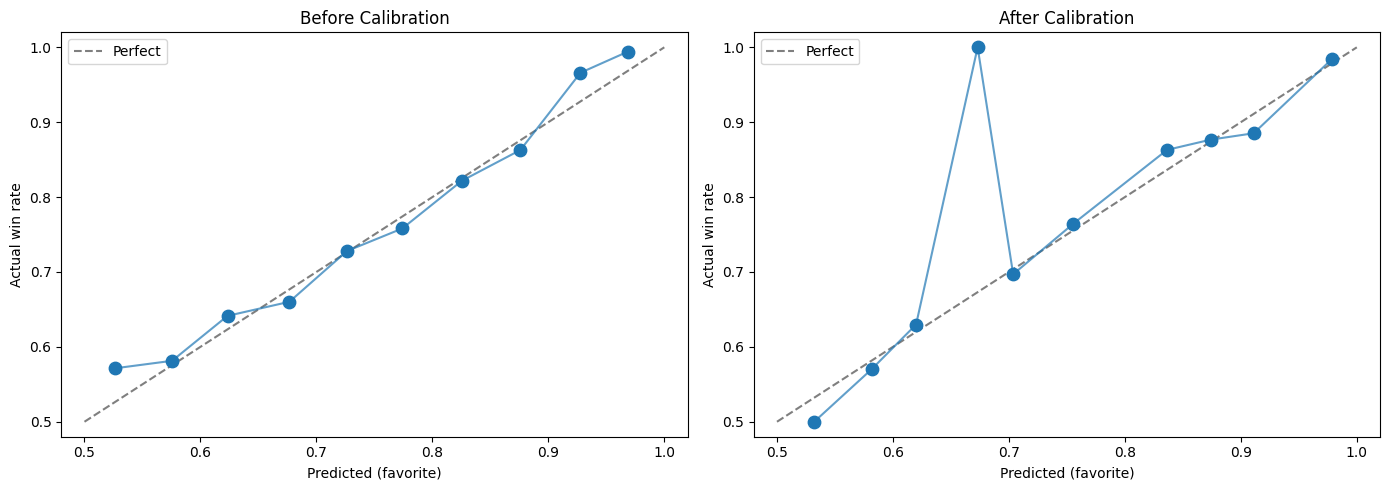

Calibration plot saved to artifacts/calibration_v3.png


In [16]:
# === Calibration Curve ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, label, preds in [
    (axes[0], "Before Calibration", oof_ensemble),
    (axes[1], "After Calibration", oof_calibrated),
]:
    mask = valid_mask & ~np.isnan(preds)
    p = preds[mask]
    a = y[mask]

    # Bin by favorite's probability
    fav_p = np.where(p >= 0.5, p, 1 - p)
    fav_a = np.where(p >= 0.5, a, 1 - a)

    bins = np.linspace(0.5, 1.0, 11)
    bin_centers = []
    bin_pred = []
    bin_actual = []

    for i in range(len(bins) - 1):
        idx = (fav_p >= bins[i]) & (fav_p < bins[i + 1])
        if idx.sum() > 0:
            bin_centers.append((bins[i] + bins[i + 1]) / 2)
            bin_pred.append(fav_p[idx].mean())
            bin_actual.append(fav_a[idx].mean())

    ax.plot([0.5, 1], [0.5, 1], "k--", alpha=0.5, label="Perfect")
    ax.scatter(bin_pred, bin_actual, s=80, zorder=5)
    ax.plot(bin_pred, bin_actual, alpha=0.7)
    ax.set_xlabel("Predicted (favorite)")
    ax.set_ylabel("Actual win rate")
    ax.set_title(label)
    ax.legend()
    ax.set_xlim(0.48, 1.02)
    ax.set_ylim(0.48, 1.02)

plt.tight_layout()
plt.savefig("artifacts/calibration_v3.png", dpi=150, bbox_inches="tight")
plt.show()
print("Calibration plot saved to artifacts/calibration_v3.png")

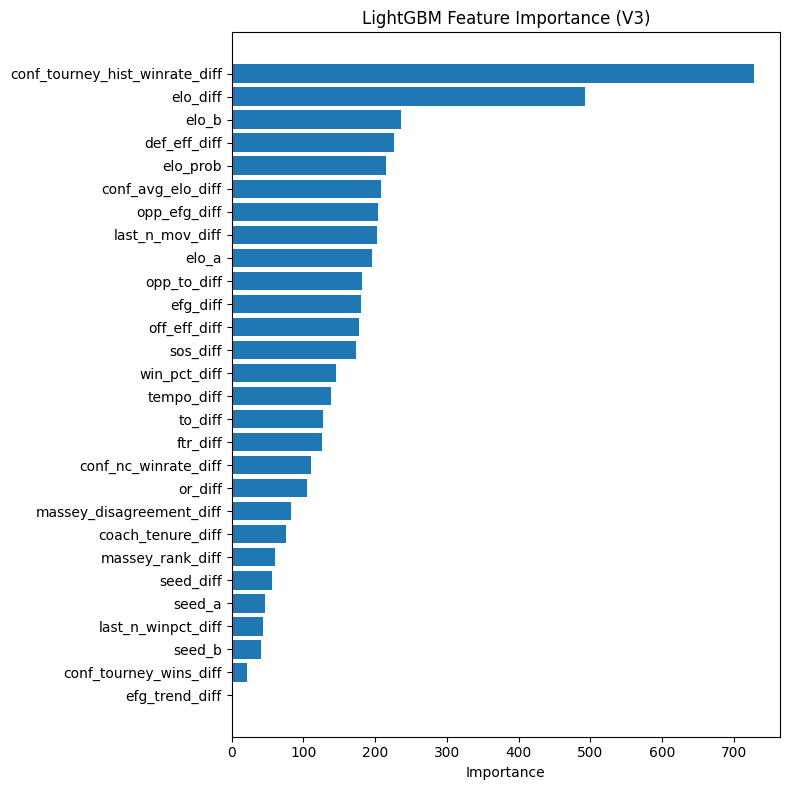

In [17]:
# === Feature Importance (LightGBM) ===
# Train on all data for importance analysis
lgb_full = lgb.LGBMClassifier(**LGB_PARAMS)
lgb_full.fit(X[valid_mask], y[valid_mask])

importance = pd.DataFrame({
    "feature": FEATURE_COLS,
    "importance": lgb_full.feature_importances_,
}).sort_values("importance", ascending=True)

fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(importance["feature"], importance["importance"])
ax.set_title("LightGBM Feature Importance (V3)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig("artifacts/feature_importance_v3.png", dpi=150, bbox_inches="tight")
plt.show()

## Part 6 — Final Model Training & Export

Train on ALL modern-era data (2012-2025), generate 2026 predictions,
and export model artifacts for live deployment.

In [18]:
# === Train Final Models ===
final_mask = seasons >= MIN_TRAIN_SEASON
X_final = X[final_mask]
y_final = y[final_mask]

print(f"Final training set: {X_final.shape[0]} games ({MIN_TRAIN_SEASON}-2025)")

# Logistic Regression
lr_final = LogisticRegression(C=0.5, max_iter=1000, random_state=42)
lr_final.fit(X_final, y_final)

# LightGBM
lgb_final = lgb.LGBMClassifier(**LGB_PARAMS)
lgb_final.fit(X_final, y_final)

# Calibrator is already fitted on OOF predictions (no refit needed)
print("Final models trained.")
print(f"Ensemble weights: LR={W_LR:.3f}, LGB={W_LGB:.3f}")

Final training set: 1705 games (2012-2025)
Final models trained.
Ensemble weights: LR=0.378, LGB=0.622


In [19]:
# === Generate Kaggle Submissions ===

def generate_submission(sample_path, output_path):
    """Generate predictions for all matchups in the sample submission."""
    sample = pd.read_csv(DATA_DIR / sample_path)
    print(f"Generating {len(sample):,} predictions for {output_path}...")

    preds = []
    for _, row in sample.iterrows():
        parts = row["ID"].split("_")
        season = int(parts[0])
        team_a = int(parts[1])
        team_b = int(parts[2])

        feat = build_matchup_row(season, team_a, team_b, elo_snapshots, seeds_lookup,
                                  conf_strength, team_conf_map, box_features,
                                  massey_features, season_features)
        X_pred = np.array([feat])

        prob_lr = lr_final.predict_proba(X_pred)[0][1]
        prob_lgb = lgb_final.predict_proba(X_pred)[0][1]

        combined = W_LR * prob_lr + W_LGB * prob_lgb
        calibrated = calibrator.predict(np.array([[combined]]))[0]
        calibrated = float(np.clip(calibrated, 0.02, 0.98))

        preds.append(calibrated)

    submission = sample[["ID"]].copy()
    submission["Pred"] = preds
    submission.to_csv(SUBMISSION_DIR / output_path, index=False)
    print(f"  Saved to {SUBMISSION_DIR / output_path}")
    print(f"  Pred range: [{min(preds):.4f}, {max(preds):.4f}]")
    print(f"  Pred mean:  {np.mean(preds):.4f}")
    return submission

# Stage 1 (validation: 2022-2025 tournament games)
stage1 = generate_submission("SampleSubmissionStage1.csv", "stage1_submission_v3_modern.csv")
print()
# Stage 2 (2026 predictions)
stage2 = generate_submission("SampleSubmissionStage2.csv", "stage2_submission_v3_modern.csv")

Generating 519,144 predictions for stage1_submission_v3_modern.csv...
  Saved to submissions/stage1_submission_v3_modern.csv
  Pred range: [0.0200, 0.9800]
  Pred mean:  0.4805

Generating 132,133 predictions for stage2_submission_v3_modern.csv...
  Saved to submissions/stage2_submission_v3_modern.csv
  Pred range: [0.0200, 0.9800]
  Pred mean:  0.4821


## Part 7 — Model Artifact Export

Save trained models for live deployment. Upload to the `model_artifacts` DB table
using `backend/scripts/upload_model_artifacts.py`.

In [20]:
# === Save Model Artifacts ===

# 1. Logistic Regression
lr_path = ARTIFACT_DIR / "lr_v3.joblib"
joblib.dump(lr_final, lr_path)
print(f"Saved LR model: {lr_path} ({lr_path.stat().st_size / 1024:.1f} KB)")

# 2. LightGBM
lgb_path = ARTIFACT_DIR / "lgb_v3.joblib"
joblib.dump(lgb_final, lgb_path)
print(f"Saved LGB model: {lgb_path} ({lgb_path.stat().st_size / 1024:.1f} KB)")

# 3. Calibrator
cal_path = ARTIFACT_DIR / "calibrator_v3.joblib"
joblib.dump(calibrator, cal_path)
print(f"Saved calibrator: {cal_path} ({cal_path.stat().st_size / 1024:.1f} KB)")

# 4. Metadata
metadata = {
    "version": "v3",
    "feature_cols": FEATURE_COLS,
    "weights": {"lr": round(W_LR, 4), "lgb": round(W_LGB, 4)},
    "elo_params": {
        "k_factor": K_FACTOR,
        "home_adv": HOME_ADV,
        "season_regression": SEASON_REGRESSION,
        "mean_elo": MEAN_ELO,
    },
    "training": {
        "min_season": MIN_TRAIN_SEASON,
        "include_conf_tourney": INCLUDE_CONF_TOURNEY,
        "n_training_games": int(X_final.shape[0]),
        "n_features": len(FEATURE_COLS),
    },
    "lgb_params": LGB_PARAMS,
    "cv_brier_calibrated": round(calibrated_brier, 4),
}

meta_path = ARTIFACT_DIR / "model_metadata_v3.json"
with open(meta_path, "w") as f:
    json.dump(metadata, f, indent=2)
print(f"Saved metadata: {meta_path}")

print(f"\n{'='*50}")
print(f"V3 MODEL SUMMARY")
print(f"{'='*50}")
print(f"Training range:    {MIN_TRAIN_SEASON}-2025")
print(f"Training games:    {X_final.shape[0]}")
print(f"Features:          {len(FEATURE_COLS)}")
print(f"Ensemble weights:  LR={W_LR:.3f}, LGB={W_LGB:.3f}")
print(f"CV Brier (calib):  {calibrated_brier:.4f}")
print(f"Elo params:        K={K_FACTOR:.1f}, Home={HOME_ADV:.1f}, Reg={SEASON_REGRESSION:.3f}")
print(f"\nArtifacts saved to: {ARTIFACT_DIR.resolve()}")
print(f"\nNext step: Upload artifacts to DB with:")
print(f"  python -m scripts.upload_model_artifacts")

Saved LR model: artifacts/lr_v3.joblib (1.0 KB)
Saved LGB model: artifacts/lgb_v3.joblib (606.0 KB)
Saved calibrator: artifacts/calibrator_v3.joblib (1.1 KB)
Saved metadata: artifacts/model_metadata_v3.json

V3 MODEL SUMMARY
Training range:    2012-2025
Training games:    1705
Features:          28
Ensemble weights:  LR=0.378, LGB=0.622
CV Brier (calib):  0.1543
Elo params:        K=19.6, Home=90.9, Reg=0.950

Artifacts saved to: /Users/richardpallangyo/Desktop/Github/ubunifu-madness/notebooks/artifacts

Next step: Upload artifacts to DB with:
  python -m scripts.upload_model_artifacts
